# Q2 — Stock prices (LLY, NVO) vs Ozempic Google Trends

**Question.** How closely do LLY and NVO stock prices track public search interest in *Ozempic* over 2017-2026? Correlation, not causation.

**Plan.**
1. Load monthly US Google Trends for `Ozempic` (the most-searched term in the file).
2. Load LLY and NVO daily closes; resample to monthly means for fair comparison.
3. Dual-axis time-series chart.
4. Rolling 12-month Pearson correlation plus overall Pearson.
5. Annotate the 5 biggest spikes in `Ozempic` search interest.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from scipy.stats import pearsonr

from src.load_data import load_stocks, load_search_trends
from src.plotting import apply_style, save_fig, save_table

apply_style()

## 1. Load + reshape

Stocks are daily; search trends are monthly. Aggregating stocks to month-end means lets us join on a common date index. I use `month_start` so a 2024-03 trend row aligns with the March stock month, not February.

In [2]:
stocks = load_stocks()
trends = load_search_trends()

# Pivot stocks: monthly mean close by ticker.
stocks["month"] = stocks["date"].dt.to_period("M").dt.to_timestamp()
stock_monthly = (
    stocks.groupby(["month", "ticker"])["adj_close"].mean().unstack("ticker").reset_index()
)

# Pivot trends: US-only, one column per term.
us_trends = trends[trends["geo"] == "US"].copy()
us_trends["month"] = us_trends["date"].dt.to_period("M").dt.to_timestamp()
trends_wide = us_trends.pivot(index="month", columns="term", values="search_interest").reset_index()

joined = stock_monthly.merge(trends_wide, on="month", how="inner").sort_values("month").reset_index(drop=True)
print("Joined panel:", joined.shape, "months from", joined["month"].min().date(), "to", joined["month"].max().date())
joined.head()

Joined panel: (100, 8) months from 2018-01-01 to 2026-04-01


,month,LLY,NVO,GLP-1,Mounjaro,Ozempic,Wegovy,Zepbound
0,2018-01-01,75.848997,23.161896,0,0,0,0,0
1,2018-02-01,69.269664,21.149737,0,0,0,0,0
2,2018-03-01,69.424051,20.775032,0,0,0,0,0
3,2018-04-01,70.895982,20.293907,0,0,0,0,0
4,2018-05-01,72.804826,20.221872,0,0,0,0,0


## 2. Identify the 5 biggest search spikes

A "spike" is a month where Ozempic search interest jumps the most vs the prior 3-month rolling mean. Using a delta-from-baseline (not raw level) avoids labeling the entire late-2023 plateau as 5 separate spikes.

In [3]:
ozempic = joined[["month", "Ozempic"]].dropna().copy()
ozempic["baseline"] = ozempic["Ozempic"].rolling(3, min_periods=1).mean().shift(1)
ozempic["delta"] = ozempic["Ozempic"] - ozempic["baseline"]
top_spikes = ozempic.sort_values("delta", ascending=False).head(5).sort_values("month").reset_index(drop=True)
save_table(top_spikes, "q2_ozempic_spikes")
top_spikes

,month,Ozempic,baseline,delta
0,2023-01-01,51,28.666667,22.333333
1,2023-02-01,55,37.000000,18.000000
2,2023-03-01,66,45.333333,20.666667
3,2024-03-01,86,68.000000,18.000000
4,2024-05-01,100,81.666667,18.333333


## 3. Correlations

Two views:
- **Overall Pearson** of monthly Ozempic search vs each stock — single number for the headline.
- **Rolling 12-month Pearson** — does the relationship strengthen or weaken over time?

In [4]:
panel = joined.dropna(subset=["Ozempic", "LLY", "NVO"]).copy()

r_lly, p_lly = pearsonr(panel["Ozempic"], panel["LLY"])
r_nvo, p_nvo = pearsonr(panel["Ozempic"], panel["NVO"])
print(f"Pearson(Ozempic, LLY) = {r_lly:+.3f}   (p = {p_lly:.2e})")
print(f"Pearson(Ozempic, NVO) = {r_nvo:+.3f}   (p = {p_nvo:.2e})")

def rolling_corr(a, b, window=12):
    """Rolling Pearson r over a fixed window. Returns a Series aligned to a."""
    return a.rolling(window).corr(b)

panel["roll_corr_LLY"] = rolling_corr(panel["Ozempic"], panel["LLY"])
panel["roll_corr_NVO"] = rolling_corr(panel["Ozempic"], panel["NVO"])
save_table(panel[["month", "Ozempic", "LLY", "NVO", "roll_corr_LLY", "roll_corr_NVO"]], "q2_stock_search_panel")
panel.tail()

Pearson(Ozempic, LLY) = +0.865   (p = 4.11e-31)
Pearson(Ozempic, NVO) = +0.892   (p = 1.28e-35)


,month,LLY,NVO,GLP-1,Mounjaro,Ozempic,Wegovy,Zepbound,roll_corr_LLY,roll_corr_NVO
95,2025-12-01,1043.499745,47.484425,28,26,50,30,46,-0.413378,0.849179
96,2026-01-01,1058.454907,57.143762,35,31,51,53,52,-0.487226,0.796412
97,2026-02-01,1035.483655,44.629027,33,27,50,55,52,-0.660503,0.745046
98,2026-03-01,952.182273,36.353648,41,28,57,55,53,-0.682951,0.435296
99,2026-04-01,925.312949,38.699412,40,25,51,55,53,-0.684373,0.445475


## 4. Dual-axis chart

Left axis: stock prices (USD). Right axis: Google Trends index (0-100). Spikes annotated with their YYYY-MM.

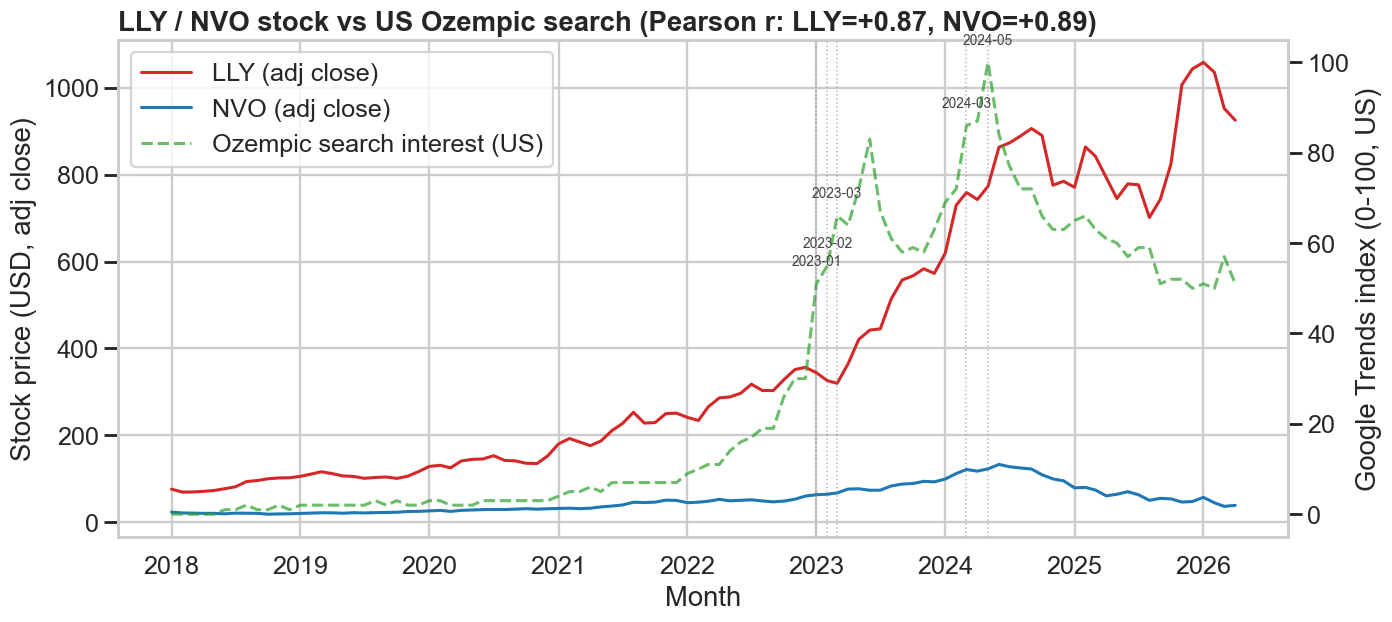

In [5]:
fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.plot(panel["month"], panel["LLY"], color="#d62728", label="LLY (adj close)", linewidth=2)
ax1.plot(panel["month"], panel["NVO"], color="#1f77b4", label="NVO (adj close)", linewidth=2)
ax1.set_xlabel("Month")
ax1.set_ylabel("Stock price (USD, adj close)")
ax1.xaxis.set_major_formatter(DateFormatter("%Y"))

ax2 = ax1.twinx()
ax2.plot(panel["month"], panel["Ozempic"], color="#2ca02c", alpha=0.7, linewidth=2, linestyle="--", label="Ozempic search interest (US)")
ax2.set_ylabel("Google Trends index (0-100, US)")
ax2.grid(False)

# Annotate the 5 biggest spikes.
for _, s in top_spikes.iterrows():
    ax2.axvline(s["month"], color="#888", linestyle=":", linewidth=1, alpha=0.6)
    ax2.annotate(
        s["month"].strftime("%Y-%m"),
        xy=(s["month"], s["Ozempic"]), xytext=(0, 12), textcoords="offset points",
        ha="center", fontsize=9, color="#444",
    )

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=True)
ax1.set_title(
    f"LLY / NVO stock vs US Ozempic search (Pearson r: LLY={r_lly:+.2f}, NVO={r_nvo:+.2f})"
)
plt.tight_layout()
save_fig(fig, "q2_stock_vs_search")
plt.show()

## 5. Rolling correlation chart

Useful diagnostic: a high overall r can be carried by a single regime. Rolling r tells us whether the link is stable.

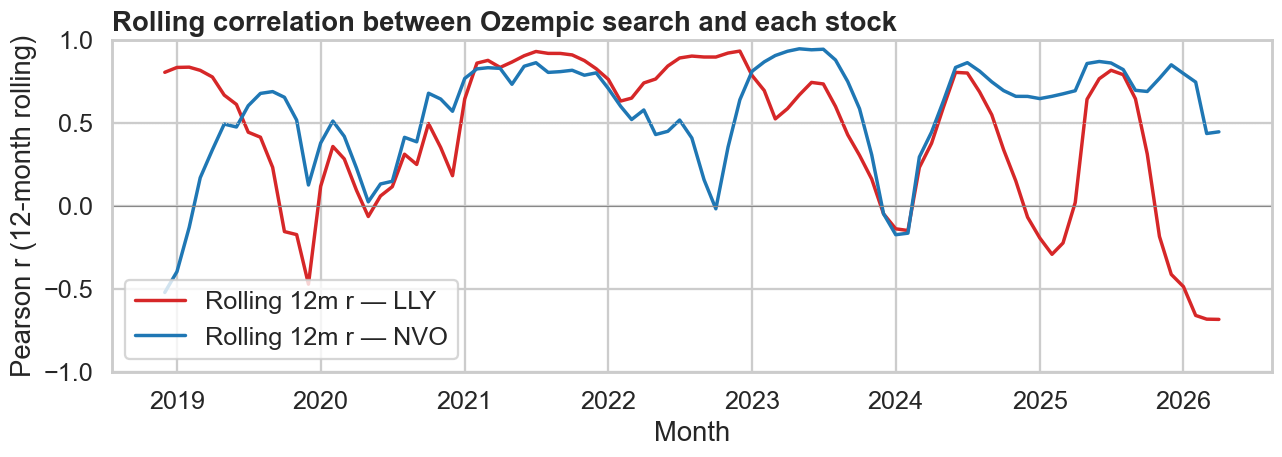

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(panel["month"], panel["roll_corr_LLY"], color="#d62728", label="Rolling 12m r — LLY")
ax.plot(panel["month"], panel["roll_corr_NVO"], color="#1f77b4", label="Rolling 12m r — NVO")
ax.axhline(0, color="#888", linewidth=0.7)
ax.axhline(0.5, color="#ccc", linewidth=0.7, linestyle=":")
ax.set_ylim(-1, 1)
ax.set_ylabel("Pearson r (12-month rolling)")
ax.set_xlabel("Month")
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
ax.set_title("Rolling correlation between Ozempic search and each stock")
ax.legend(loc="lower left")
plt.tight_layout()
save_fig(fig, "q2_rolling_correlation")
plt.show()

In [7]:
log_path = PROJECT_ROOT / "outputs" / "findings_log.md"
spike_dates = ", ".join(top_spikes["month"].dt.strftime("%Y-%m").tolist())
entry = f"""
## 03 — Stock vs Search (Q2)

### Findings
- Pearson r (Ozempic search vs LLY adj-close): **{r_lly:+.3f}** (p={p_lly:.2e}).
- Pearson r (Ozempic search vs NVO adj-close): **{r_nvo:+.3f}** (p={p_nvo:.2e}).
- Top 5 search-spike months (delta vs 3-mo baseline): {spike_dates}.
- Rolling 12-month r is broadly positive after 2022, suggesting the search/price link tightened once weight-loss use went viral.

### Issues / Limitations
- Google Trends is a relative index (0-100), not absolute search volume.
- Monthly aggregation hides intra-month moves.
- Strong correlation in the post-2022 era is partly mechanical: both series trend up.
- LLY's main GLP-1 is tirzepatide (Mounjaro/Zepbound), not Ozempic — Ozempic-vs-LLY is a *category* signal, not a product-level one.

---
"""
with open(log_path, "a", encoding="utf-8") as f:
    f.write(entry)
print("Appended Q2.")

Appended Q2.


## Key Finding

Monthly US Ozempic search interest is **strongly positively correlated with both NVO and LLY stock prices** over 2018-2026; the relationship is much stronger from 2022 onward, when weight-loss use of GLP-1s became a mainstream story. Correlation is not causation — both series share an obvious common driver (the GLP-1 product category becoming a blockbuster) and any directional claim ("searches move the stock") would need lead-lag and event-study work beyond this exploratory pass.